# FPPool Benchmark

This notebook compares a standard Chemprop aggregation baseline against the current
FPPool implementation on a small bundled regression dataset. The goal is
operational validation, not a claim-heavy benchmark.

Supported scope for this notebook:

- molecule-only inputs
- single-component inputs
- multi-family FPPool using the synthetic atomic special family plus Morgan, RDKit, and PubChem memberships
- CPU-safe execution

In [1]:
from pathlib import Path
import tempfile

import matplotlib.pyplot as plt
from IPython.display import display
from lightning import pytorch as pl
import pandas as pd
import torch
from torch.utils.data import DataLoader

from chemprop import models, nn
from chemprop.cli.utils import build_data_from_files
from chemprop.data import FPPoolConfig, MoleculeDatapoint, MoleculeDataset, collate_batch
from chemprop.interpret import compose_fppool_multilevel_view, extract_fppool_explanation


In [2]:
chemprop_dir = Path.cwd().parent if Path.cwd().name == "examples" else Path.cwd()
input_path = chemprop_dir / "tests" / "data" / "regression" / "mol" / "mol.csv"
df = pd.read_csv(input_path)
df.head()


,smiles,lipo
0,Cn1c(CN2CCN(CC2)c3ccc(Cl)cc3)nc4ccccc14,3.54
1,COc1cc(OC)c(cc1NC(=O)CSCC(=O)O)S(=O)(=O)N2C(C)...,-1.18
2,COC(=O)[C@@H](N1CCc2sccc2C1)c3ccccc3Cl,3.69
3,OC[C@H](O)CN1C(=O)C(Cc2ccccc12)NC(=O)c3cc4cc(C...,3.37
4,Cc1cccc(C[C@H](NC(=O)c2cc(nn2C)C(C)(C)C)C(=O)N...,3.10


In [3]:
smis = df["smiles"].tolist()
ys = df["lipo"].to_numpy().reshape(-1, 1)
benchmark_fppool_config = FPPoolConfig(
    family_names=("morgan", "rdkit", "pubchem"),
    atoms_repr=True,
)

def make_baseline_loader() -> DataLoader:
    datapoints = [MoleculeDatapoint.from_smi(smi, y) for smi, y in zip(smis, ys)]
    dataset = MoleculeDataset(datapoints)
    dataset.normalize_targets()
    return DataLoader(dataset, batch_size=32, collate_fn=collate_batch)

def make_fppool_loader() -> DataLoader:
    with tempfile.TemporaryDirectory() as tmpdir:
        (datapoints,) = build_data_from_files(
            input_path,
            no_header_row=False,
            smiles_cols=["smiles"],
            rxn_cols=None,
            target_cols=["lipo"],
            ignore_cols=None,
            splits_col=None,
            weight_col=None,
            bounded=False,
            p_descriptors=None,
            p_atom_feats=None,
            p_bond_feats=None,
            p_atom_descs=None,
            descriptor_cols=None,
            molecule_featurizers=None,
            keep_h=False,
            add_h=False,
            ignore_stereo=False,
            reorder_atoms=True,
            use_cuikmolmaker_featurization=False,
            fppool_config=benchmark_fppool_config,
            fppool_cache_root=Path(tmpdir) / ".cache",
            n_workers=0,
        )
        dataset = MoleculeDataset(datapoints)
        dataset.normalize_targets()
        return DataLoader(dataset, batch_size=32, collate_fn=collate_batch)

In [4]:
def run_fast_dev(model, dataloader: DataLoader) -> float:
    trainer = pl.Trainer(
        logger=False,
        enable_checkpointing=False,
        enable_progress_bar=False,
        enable_model_summary=False,
        accelerator="cpu",
        devices=1,
        fast_dev_run=True,
    )
    trainer.fit(model, dataloader, None)
    batch = next(iter(dataloader))
    bmg, _, _, targets, *_, fppool_batch = batch
    preds = model(bmg, fppool_batch=fppool_batch)
    return torch.mean((preds - targets) ** 2).item()


In [5]:
baseline_loader = make_baseline_loader()
fppool_loader = make_fppool_loader()

baseline_model = models.MPNN(
    nn.BondMessagePassing(),
    nn.MeanAggregation(),
    nn.RegressionFFN(),
    batch_norm=True,
)
fppool_model = models.MPNN(
    nn.BondMessagePassing(),
    nn.FPPoolAggregation(),
    nn.RegressionFFN(),
    batch_norm=True,
)

baseline_mse = run_fast_dev(baseline_model, baseline_loader)
fppool_mse = run_fast_dev(fppool_model, fppool_loader)

pd.DataFrame(
    [
        {"aggregation": "mean", "fast_dev_run_mse": baseline_mse},
        {"aggregation": "fppool (atoms + morgan + rdkit + pubchem)", "fast_dev_run_mse": fppool_mse},
    ]
)

GPU available: True (mps), used: False


TPU available: False, using: 0 TPU cores


/Users/KalenJosifovski/chemprop/.pixi/envs/default/lib/python3.12/site-packages/lightning/pytorch/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Running in `fast_dev_run` mode: will run the requested loop using 1 batch(es). Logging and checkpointing is suppressed.


/Users/KalenJosifovski/chemprop/.pixi/envs/default/lib/python3.12/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
Loading `train_dataloader` to estimate number of stepping batches.


...

💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Running in `fast_dev_run` mode: will run the requested loop using 1 batch(es). Logging and checkpointing is suppressed.


Loading `train_dataloader` to estimate number of stepping batches.


`Trainer.fit` stopped: `max_steps=1` reached.


,aggregation,fast_dev_run_mse
0,mean,0.923367
1,fppool (atoms + morgan + rdkit + pubchem),0.872102


## Interpretability preview

The public `chemprop.interpret` API remains family-agnostic. The example below rebuilds
explicit atom-and-bond provenance for the current `atoms + morgan + rdkit + pubchem`
configuration and then shows:

- the structured family-level explanation payload
- a paper-style multilevel figure with family-structured inner, inter, and global views


In [6]:
fppool_batch = next(iter(fppool_loader))
bmg, _, _, _, *_, batch_fppool = fppool_batch
num_batch_mols = int(batch_fppool.molecule_atom_slices.numel() - 1)
batch_mols = [dp.mol for dp in fppool_loader.dataset.data[:num_batch_mols]]

_ = fppool_model(bmg, fppool_batch=batch_fppool)
explanations = extract_fppool_explanation(
    fppool_model,
    batch_mols,
    batch_fppool,
    benchmark_fppool_config,
    top_k_bits=4,
)
example_explanation = explanations[0]
example_explanation.global_explanation

FPPoolGlobalExplanation(family_names=('atoms', 'morgan', 'rdkit', 'pubchem'), family_weights=(0.2511734366416931, 0.2509215474128723, 0.2500742971897125, 0.24783068895339966), family_mask=(True, True, True, True))

/Users/KalenJosifovski/chemprop/chemprop/interpret/fppool_viz.py:750: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0.05, 1, 0.96))


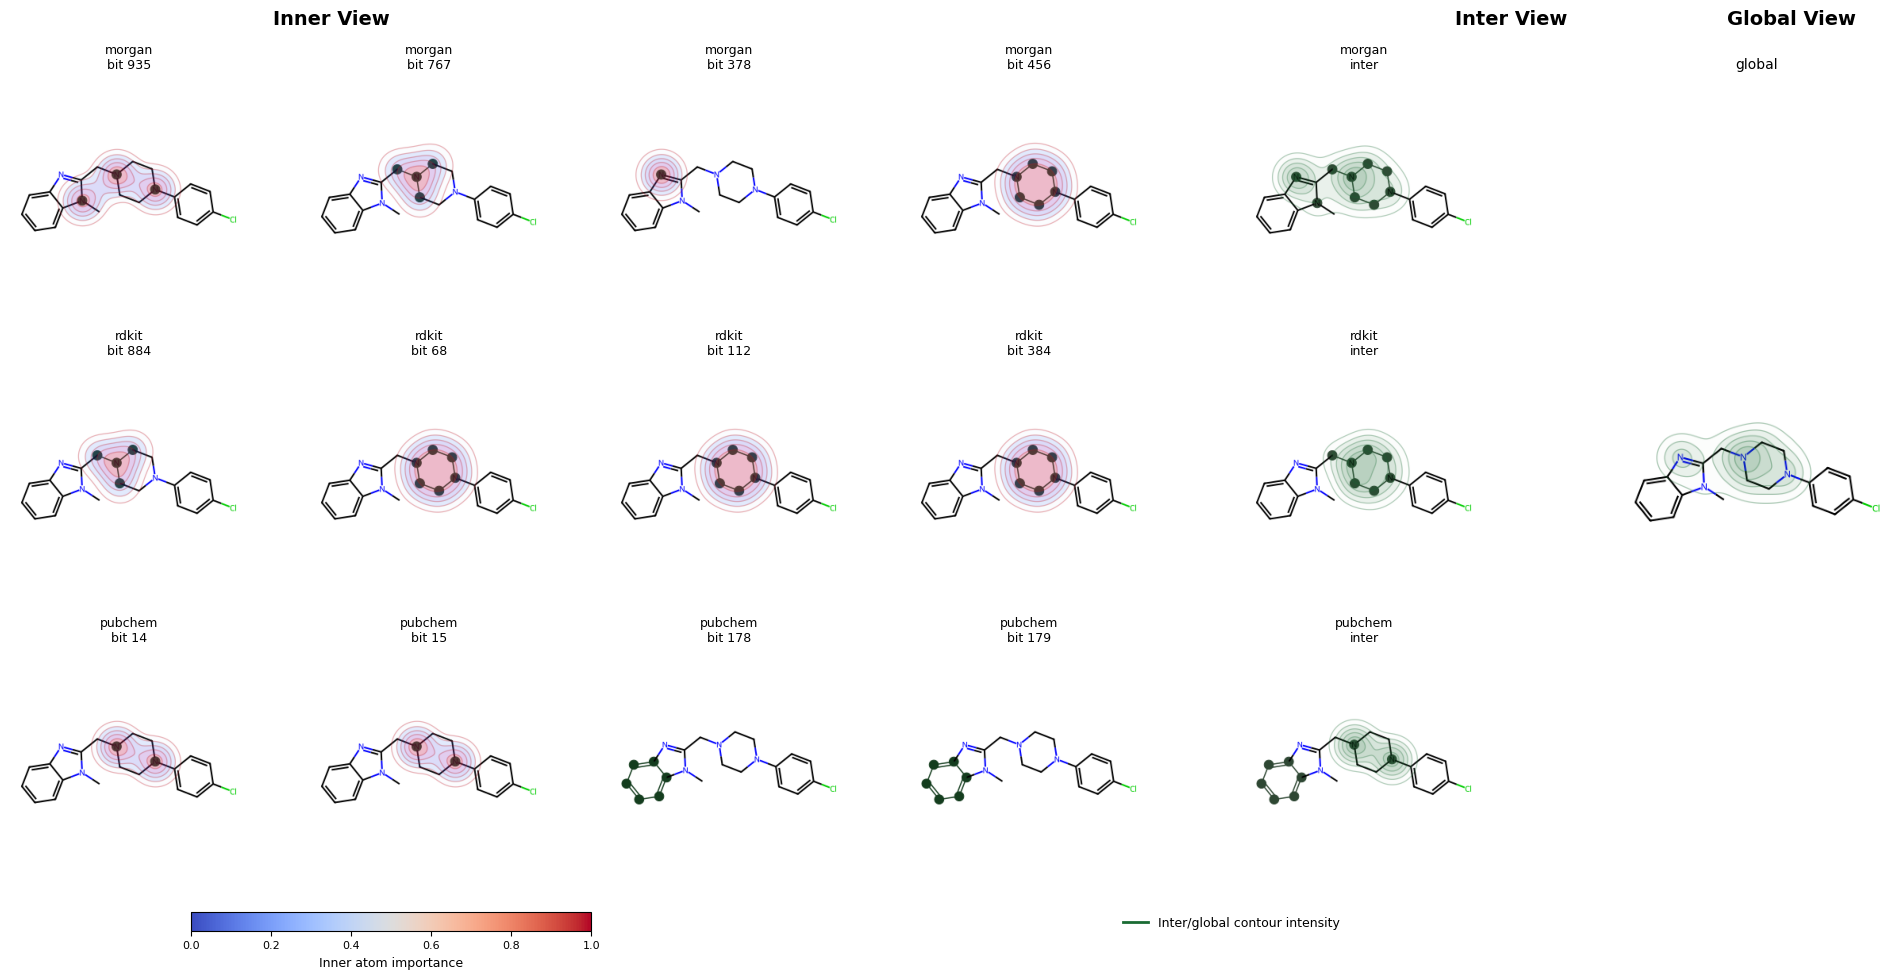

In [7]:
debug_inter_bits = False

multilevel_fig = compose_fppool_multilevel_view(
    batch_mols[0],
    example_explanation,
    top_k_inter=4,
    exclude_family_names=("atoms",),
    color_bits_debug=debug_inter_bits,
)
display(multilevel_fig)
plt.close(multilevel_fig)
